In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_curve

from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay


In [2]:
df=pd.read_csv('data/df_limpio.csv')
df.head()


,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima
0,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,Escolar,Desempleado,Soltero,1.0,1.0,Vivienda,0.0,0,65.85
1,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,Máster,Jornada completa,Casado,1.0,1.0,Vivienda,0.0,0,260.60
2,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,Grado Universitario,Jornada completa,Casado,0.0,1.0,Vivienda,1.0,0,221.02
3,YL0W8G,30,31923.0,36707,813,43.0,1,8.96,24.0,0.32,Grado Universitario,Jornada completa,Casado,0.0,1.0,Vivienda,0.0,0,125.00
4,YP8WTV,28,27373.0,86981,765,60.0,2,10.07,48.0,0.55,Escolar,Jornada completa,Soltero,0.0,1.0,Vivienda,0.0,0,800.00


In [3]:
df.describe()

,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Posesion_Hipoteca,Personas_Cargo,Fiador,Impago,Prima
count,101899.000000,101899.000000,101899.0000,101899.000000,101899.000000,101899.000000,101899.000000,101899.000000,101899.000000,101899.000000,101899.000000,101899.000000,101899.000000,101899.000000
mean,39.665728,41502.751784,45009.4313,692.305322,212.913925,1.998126,10.670148,37.251133,0.321384,0.351835,0.449096,0.298661,0.115114,384.712288
std,10.103243,16033.982121,46628.3117,87.517421,151.096147,0.998255,3.797937,14.155286,0.181192,0.477541,0.497402,0.457671,0.319161,267.145901
min,19.000000,16000.000000,3000.0000,398.000000,0.000000,1.000000,2.010000,12.000000,0.100000,0.000000,0.000000,0.000000,0.000000,10.000000
25%,33.000000,30468.000000,14995.0000,636.000000,69.000000,1.000000,7.960000,24.000000,0.140000,0.000000,0.000000,0.000000,0.000000,137.470000
50%,40.000000,39082.000000,40000.0000,704.000000,208.000000,2.000000,10.600000,36.000000,0.290000,0.000000,0.000000,0.000000,0.000000,336.280000
75%,46.000000,50136.000000,47398.0000,761.000000,337.000000,3.000000,13.260000,48.000000,0.550000,1.000000,1.000000,1.000000,0.000000,610.695000
max,64.000000,120000.000000,400000.0000,845.000000,628.000000,4.000000,24.440000,60.000000,0.550000,1.000000,1.000000,1.000000,1.000000,800.000000


Seguramente el `Scoring_Crediticio` por los datos que hay, en esta entidad su rango se encuentre desde 300 hasta 850 

In [4]:
copy=df.copy()
# hacemos copia por si acaso queremos ver la forma original en algun momento

In [5]:
copy.dtypes

ID                       object
Edad                      int64
Ingresos                float64
Monto_Inicial             int64
Scoring_Crediticio        int64
Meses_Empleo            float64
Num_Creditos              int64
Ratio_Interes           float64
Duracion                float64
Ratio_Deuda_Ingresos    float64
Estudios                 object
Tipo_Jornada_Laboral     object
Estado_Civil             object
Posesion_Hipoteca       float64
Personas_Cargo          float64
Proposito                object
Fiador                  float64
Impago                    int64
Prima                   float64
dtype: object

In [6]:
copy["Tipo_Jornada_Laboral"].unique()

array(['Desempleado', 'Jornada completa', 'Tiempo parcial', 'Autónomo'],
      dtype=object)

In [7]:
copy["Estado_Civil"].unique()

array(['Soltero', 'Casado', 'Divorciado'], dtype=object)

In [8]:
copy["Estudios"].unique()

array(['Escolar', 'Máster', 'Grado Universitario', 'Doctorado'],
      dtype=object)

MODELO: regresión logística ya que tenemos valores binarios (0: no impago, 1: impago)

In [9]:
# variables en escalas muy diferentes, asi que escalar. 
# variables no numéricas--> pasar a numérico (probar si una tiene mas peso que otra y usar ordinal enc, si no one hot)

In [10]:
num=copy.drop(columns=["Estudios", "Tipo_Jornada_Laboral", "Estado_Civil","ID","Proposito"])

<Axes: >

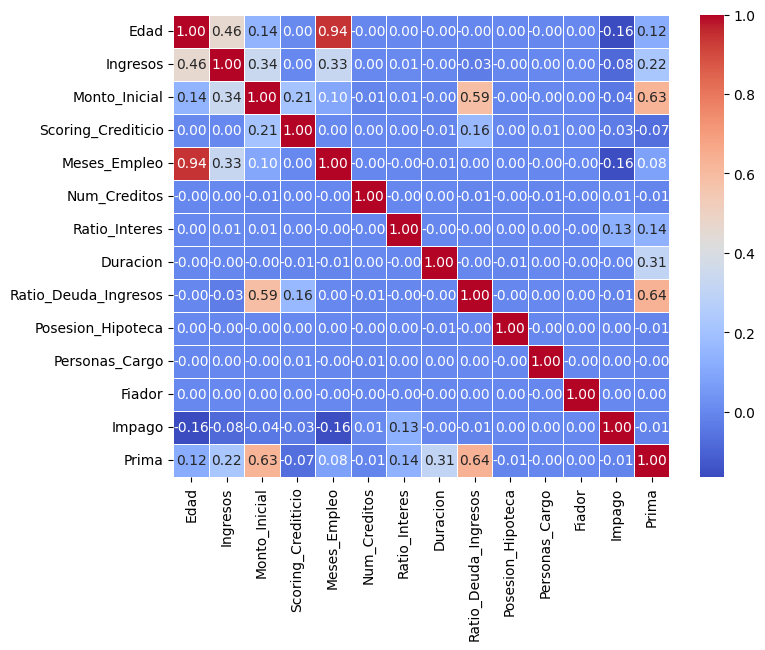

In [11]:
matriz_corr =num.corr(numeric_only=True)

# Crear la figura
plt.figure(figsize=(8, 6))

# Dibujar el mapa de calor
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

Las correlaciones lineales con nuestra variable objetivo `Impago` son en general débiles. Las más relevantes son `Edad` (0,16) y `Meses_Empleo` (0,16), que indican que a más edad y más antigüedad laboral hay menos impagos, y con `Ratio_Interes` (0,13), donde a mayor interés hay más impagos. El resto de variables tienen una correlación bastante baja.

In [12]:
copy.groupby("Estado_Civil")["Impago"].mean()

Estado_Civil
Casado        0.098282
Divorciado    0.077275
Soltero       0.167024
Name: Impago, dtype: float64

In [13]:
copy["Estado_Civil"].value_counts()

Estado_Civil
Casado        52146
Soltero       30756
Divorciado    18997
Name: count, dtype: int64

In [14]:
copy.groupby("Tipo_Jornada_Laboral")["Impago"].mean()  #aqui no existe una jerarquia

Tipo_Jornada_Laboral
Autónomo            0.118491
Desempleado         0.118453
Jornada completa    0.114570
Tiempo parcial      0.112467
Name: Impago, dtype: float64

In [15]:
copy.groupby("Estudios")["Impago"].mean()

Estudios
Doctorado              0.117589
Escolar                0.102644
Grado Universitario    0.124974
Máster                 0.121298
Name: Impago, dtype: float64

In [16]:
# en estudios y jornada no tiene sentido poner un orden, la tasa de impago es muy parecida

Se le da en la columna de `Estado_Civil` a cada categoría un valor desde la menos probabilidad (divorciado) de impago a la que más (soltero), por lo que el estado de esta variable si que afecta al nivel de riesgo

In [17]:

ordinal_enc=OrdinalEncoder(categories=[["Divorciado", "Casado", "Soltero"]])

copy[["Estado_Civil"]] = ordinal_enc.fit_transform(copy[["Estado_Civil"]])

In [18]:
copy  #df con el ordinal encoder hecho.

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima
0,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,Escolar,Desempleado,2.0,1.0,1.0,Vivienda,0.0,0,65.85
1,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,Máster,Jornada completa,1.0,1.0,1.0,Vivienda,0.0,0,260.60
2,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,Grado Universitario,Jornada completa,1.0,0.0,1.0,Vivienda,1.0,0,221.02
3,YL0W8G,30,31923.0,36707,813,43.0,1,8.96,24.0,0.32,Grado Universitario,Jornada completa,1.0,0.0,1.0,Vivienda,0.0,0,125.00
4,YP8WTV,28,27373.0,86981,765,60.0,2,10.07,48.0,0.55,Escolar,Jornada completa,2.0,0.0,1.0,Vivienda,0.0,0,800.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101894,5PM51H,29,35671.0,5681,628,27.0,2,12.11,48.0,0.10,Grado Universitario,Jornada completa,2.0,0.0,1.0,Vivienda,1.0,0,116.89
101895,L0RUJT,28,22864.0,40000,752,9.0,2,10.77,48.0,0.55,Grado Universitario,Jornada completa,1.0,0.0,1.0,Vivienda,0.0,0,607.55
101896,8OJZU0,35,69159.0,41795,699,65.0,2,10.41,36.0,0.29,Doctorado,Tiempo parcial,2.0,0.0,0.0,Vivienda,0.0,0,406.82
101897,II8B24,39,68375.0,21847,722,170.0,2,6.26,36.0,0.14,Máster,Jornada completa,1.0,0.0,1.0,Vivienda,1.0,0,125.32


Usamos **one-hot** en las dos columnas restantes categóricas porque el ordinal solo es adecuado cuando el orden de las categorías repercute en el impago, como ocurría en `Estado_Civil` . En `Estudios` las variables podrían tener un orden, pero a la columna impago no le influye especialmente (Escolar 10,3 %, Doctorado 11,8 %, Máster 12,1 %, Grado 12,5 %), y en `Tipo_Jornada_Laboral` no hay ningún orden, aunque podría ser que al trabajar durante más horas pudiera solventar un pago más rápido con este dataset no es el caso. Por tanto con one-hot cada categoría tiene su propio efecto sin imponer una jerarquía, que es lo que nos interesa.

In [19]:
# las otras dos categóricas, con one-hot
copy = pd.get_dummies(copy, columns=["Estudios", "Tipo_Jornada_Laboral"], dtype=int)

# quitamos una columna por variable (grupo de referencia) para evitar redundancia/multicolinealidad
copy = copy.drop(columns=["Estudios_Escolar", "Tipo_Jornada_Laboral_Jornada completa"])

copy.head()

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Proposito,Fiador,Impago,Prima,Estudios_Doctorado,Estudios_Grado Universitario,Estudios_Máster,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Tiempo parcial
0,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,...,Vivienda,0.0,0,65.85,0,0,0,0,1,0
1,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,...,Vivienda,0.0,0,260.60,0,0,1,0,0,0
2,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,...,Vivienda,1.0,0,221.02,0,1,0,0,0,0
3,YL0W8G,30,31923.0,36707,813,43.0,1,8.96,24.0,0.32,...,Vivienda,0.0,0,125.00,0,1,0,0,0,0
4,YP8WTV,28,27373.0,86981,765,60.0,2,10.07,48.0,0.55,...,Vivienda,0.0,0,800.00,0,0,0,0,0,0


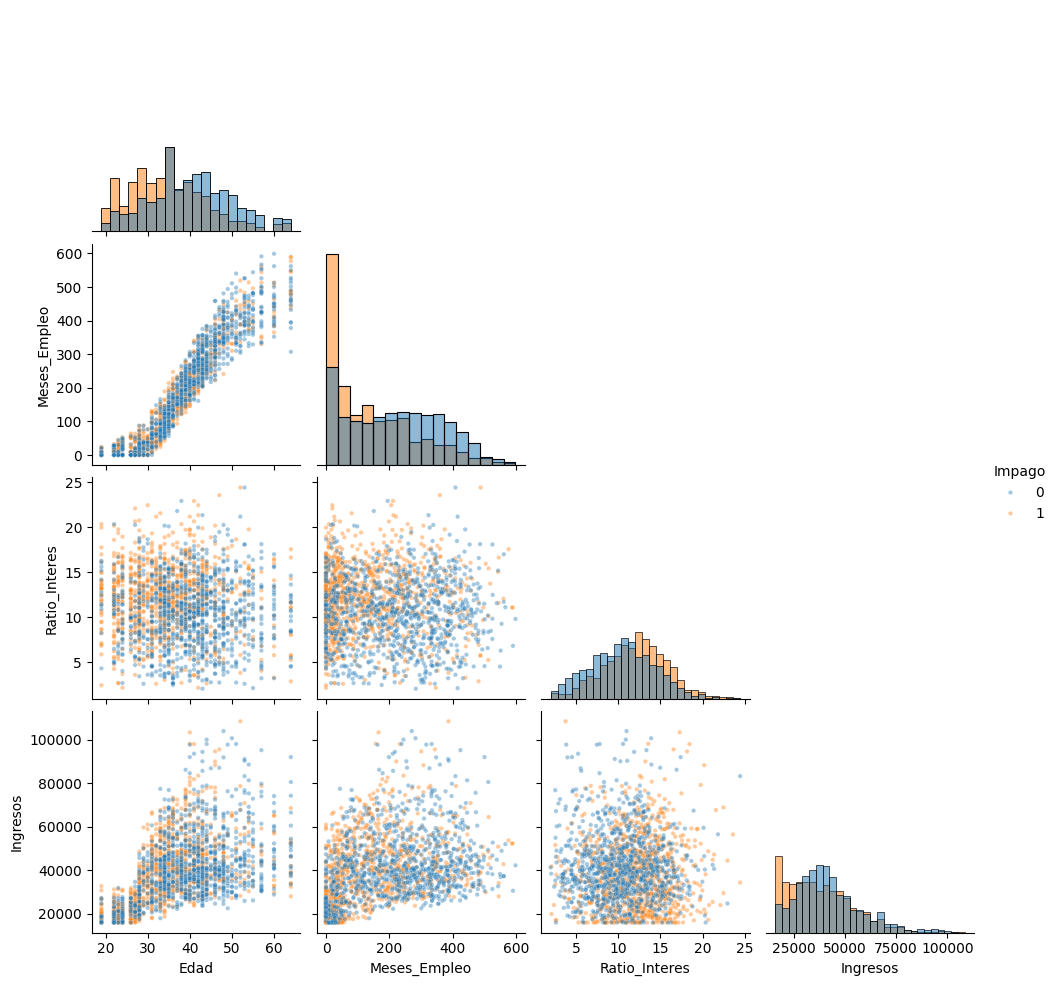

In [20]:
cols = ["Edad", "Meses_Empleo", "Ratio_Interes", "Ingresos", "Impago"]

# todos los impagos que haya en 1000 + 1000 no impagos (muestra equilibrada, se ve mejor)
muestra = pd.concat([
    copy[copy["Impago"] == 1][cols].sample(1000, random_state=42),
    copy[copy["Impago"] == 0][cols].sample(1000, random_state=42),])

sns.pairplot(
    muestra, hue="Impago", corner=True,
    diag_kind="hist",                    
    plot_kws={"alpha": 0.4, "s": 10},)
plt.show()

In [21]:
X = copy.drop(columns=["ID", "Proposito", "Impago"])
y = copy["Impago"]

In [22]:
X.columns

Index(['Edad', 'Ingresos', 'Monto_Inicial', 'Scoring_Crediticio',
       'Meses_Empleo', 'Num_Creditos', 'Ratio_Interes', 'Duracion',
       'Ratio_Deuda_Ingresos', 'Estado_Civil', 'Posesion_Hipoteca',
       'Personas_Cargo', 'Fiador', 'Prima', 'Estudios_Doctorado',
       'Estudios_Grado Universitario', 'Estudios_Máster',
       'Tipo_Jornada_Laboral_Autónomo', 'Tipo_Jornada_Laboral_Desempleado',
       'Tipo_Jornada_Laboral_Tiempo parcial'],
      dtype='object')

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y, shuffle=True)
X_train, X_test = X_train.copy(), X_test.copy()

Las variables numéricas tienen valores en escalas muy diferentes. Por ejemplo, `Ingresos` puede alcanzar valores de hasta 120.000, mientras que `Ratio_Deuda_Ingresos` tiene valores mucho más pequeños, con un max. de 0,55. Para evitar que estas diferencias afecten al funcionamiento de la regresión logística, estandarizamos las variables numéricas continuas utilizando StandardScaler.

El escalado se realiza utilizando únicamente los datos del conjunto de entrenamiento, para evitar que la información del conjunto de prueba influya en el modelo.

# ESTANDARIZACIÓN

In [24]:
# escalamos las columnas numéricas continuas, (las 0/1 se quedan como están)
cols_num = ["Edad", "Ingresos", "Monto_Inicial", "Scoring_Crediticio", "Meses_Empleo",
            "Num_Creditos", "Ratio_Interes", "Duracion", "Ratio_Deuda_Ingresos", "Prima"]

In [25]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_num] = scaler.fit_transform(X_train[cols_num])   # aprende media y desviación del train
X_test_scaled[cols_num] = scaler.transform(X_test[cols_num])         # aplica esos mismos valores al test

In [26]:
X_test_scaled[cols_num].describe().round(2)

,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Prima
count,20380.00,20380.00,20380.00,20380.00,20380.00,20380.00,20380.00,20380.00,20380.00,20380.00
mean,-0.01,-0.00,0.00,-0.00,-0.00,-0.02,0.00,0.01,0.01,0.01
std,1.00,1.00,0.99,0.99,0.99,0.99,1.00,1.00,1.00,1.00
min,-2.05,-1.59,-0.90,-3.36,-1.41,-1.00,-2.28,-1.78,-1.22,-1.40
25%,-0.66,-0.69,-0.64,-0.65,-0.95,-1.00,-0.71,-0.94,-1.00,-0.91
50%,0.03,-0.15,-0.11,0.13,-0.04,-0.00,-0.02,-0.09,-0.17,-0.16
75%,0.63,0.54,0.07,0.77,0.81,1.00,0.68,0.76,1.26,0.88
max,2.41,4.89,7.60,1.74,2.68,2.00,3.63,1.61,1.26,1.56


In [27]:
X_train_scaled[cols_num].describe().round(2)

,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Prima
count,81519.00,81519.00,81519.00,81519.00,81519.00,81519.0,81519.00,81519.00,81519.00,81519.00
mean,-0.00,0.00,0.00,0.00,-0.00,0.0,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00
min,-2.05,-1.59,-0.90,-3.36,-1.41,-1.0,-2.28,-1.78,-1.22,-1.40
25%,-0.66,-0.69,-0.64,-0.64,-0.95,-1.0,-0.71,-0.94,-1.00,-0.93
50%,0.03,-0.15,-0.11,0.13,-0.03,-0.0,-0.02,-0.09,-0.17,-0.18
75%,0.72,0.54,0.05,0.78,0.83,1.0,0.68,0.76,1.26,0.84
max,2.41,4.89,7.60,1.74,2.74,2.0,3.63,1.61,1.26,1.56


# SKLEARN

In [28]:
modelo_log_sklearn = LogisticRegression()
modelo_log_sklearn.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
print("Intercept:", modelo_log_sklearn.intercept_)
print("Accuracy de entrenamiento:", modelo_log_sklearn.score(X_train_scaled, y_train))
print("Accuracy test: ", modelo_log_sklearn.score(X_test_scaled, y_test))

Intercept: [-2.29200359]
Accuracy de entrenamiento: 0.8849102663182816
Accuracy test:  0.8848871442590776


In [30]:
pd.Series(modelo_log_sklearn.coef_.flatten(), index=X_train_scaled.columns).sort_values().round(3)

Edad                                  -0.368
Meses_Empleo                          -0.191
Scoring_Crediticio                    -0.106
Monto_Inicial                         -0.045
Estudios_Doctorado                    -0.024
Personas_Cargo                        -0.012
Tipo_Jornada_Laboral_Tiempo parcial   -0.009
Estudios_Máster                       -0.008
Duracion                              -0.006
Prima                                 -0.003
Estudios_Grado Universitario          -0.002
Ratio_Deuda_Ingresos                   0.005
Fiador                                 0.009
Ingresos                               0.011
Num_Creditos                           0.026
Posesion_Hipoteca                      0.028
Tipo_Jornada_Laboral_Autónomo          0.029
Tipo_Jornada_Laboral_Desempleado       0.044
Estado_Civil                           0.045
Ratio_Interes                          0.428
dtype: float64

## **EDITAR**

A partir de los coeficientes se puede concluir que a medida que la edad sube la probabilidad del impago disminuye, los ingresos 

In [31]:
predicciones = modelo_log_sklearn.predict_proba(X = X_test_scaled)
predicciones = pd.DataFrame(predicciones, columns = modelo_log_sklearn.classes_)

In [32]:
copy['Impago'].value_counts()

Impago
0    90169
1    11730
Name: count, dtype: int64

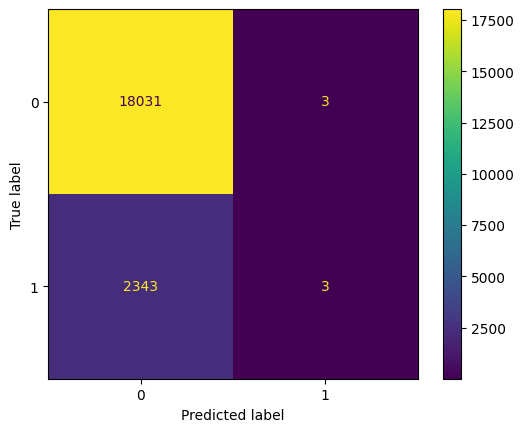

In [33]:
clases_pred = modelo_log_sklearn.predict(X_test_scaled)

ConfusionMatrixDisplay.from_predictions(y_test, clases_pred)
plt.show()

In [34]:
print("Porcentajes reales:")
print((y_test.value_counts(normalize=True) * 100).round(2))

print("Porcentajes predichos:")
print((pd.Series(clases_pred).value_counts(normalize=True) * 100).round(2))

Porcentajes reales:
Impago
0    88.49
1    11.51
Name: proportion, dtype: float64
Porcentajes predichos:
0    99.97
1     0.03
Name: proportion, dtype: float64


In [35]:
predicciones = modelo_log_sklearn.predict(X_test_scaled)
predicciones[:5]

array([0, 0, 0, 0, 0])

# AJUSTE DEL MODELO CON STATSMODEL

In [36]:
X_train_scaled = sm.add_constant(X_train_scaled, prepend=True)
modelo_log_statsm = sm.Logit(endog= y_train, exog = X_train_scaled)
modelo_log_statsm = modelo_log_statsm.fit()
print(modelo_log_statsm.summary())

Optimization terminated successfully.
         Current function value: 0.332848
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Impago   No. Observations:                81519
Model:                          Logit   Df Residuals:                    81498
Method:                           MLE   Df Model:                           20
Date:                Fri, 09 Oct 2026   Pseudo R-squ.:                 0.06785
Time:                        20:36:01   Log-Likelihood:                -27133.
converged:                       True   LL-Null:                       -29108.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  -2.2943      0.041 

In [37]:
intervalos_ci = modelo_log_statsm.conf_int(alpha=0.05).rename(columns={0: "2.5%", 1: "97.5%"})

intervalos_ci[:4]

,2.5%,97.5%
const,-2.374256,-2.214269
Edad,-0.477555,-0.287122
Ingresos,-0.032846,0.059708
Monto_Inicial,-0.082760,-0.008658


In [38]:
X_test_scaled = sm.add_constant(X_test_scaled, has_constant='add')

predicciones = modelo_log_statsm.predict(exog = X_test_scaled)
predicciones[:4]

75122    0.352954
55143    0.126432
15117    0.082433
51443    0.156043
dtype: float64

## PREDICCIÓN Y EVALUCIÓN DEL MODELO

In [ ]:
probabilidades = modelo_log_statsm.predict(X_test_scaled)  # probabilidad de impago (los números 1)
clasificacion = np.where(predicciones<0.5, 0, 1)
clasificacion[:4]

array([0, 0, 0, 0])

In [40]:
base_0 = y_test.value_counts(normalize=True).max()
print("Precisión (siendo prediciendo 0):", round(base_0 * 100, 2), "%")
print("Predicciones del modelo ->", pd.Series(clasificacion).value_counts().to_dict())
print("Valores reales en test  ->", y_test.value_counts().to_dict())

Precisión (siendo prediciendo 0): 88.49 %
Predicciones del modelo -> {0: 20374, 1: 6}
Valores reales en test  -> {0: 18034, 1: 2346}


### Métricas de rendimiento del modelo

- Accuracy

- precision

- sensibilidad (recall)

- f1-score

- Matriz de confusión

- Curva precisión/sensibilidad

- curva ROC-AUC

- ### Accuracy

In [41]:
""" Mide la proporción de predicciones correctas sobre el total de observaciones evaluadas"""

acierto = accuracy_score(y_test, clasificacion)
error = 1 - acierto

print("Acierto:", round(acierto*100, 2), "%")
print("Error:", round(error*100, 2), "%")

Acierto: 88.49 %
Error: 11.51 %


- ### Precisión, Recall, f1-score

In [42]:
""" 
Precision: Cada vez que el modelo predijo una clase, acerto ese porcentaje
Recall: De todos los datos que eran de esa clase, detectó ese porcentaje
F1-score: El valor será alto si precisión y sensibilidad son similares, útil para comparar clasificadores.
"""

print(classification_report(y_test, clasificacion))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18034
           1       0.50      0.00      0.00      2346

    accuracy                           0.88     20380
   macro avg       0.69      0.50      0.47     20380
weighted avg       0.84      0.88      0.83     20380



- ### Matriz de confusión

[[18031     3]
 [ 2343     3]]


<Axes: >

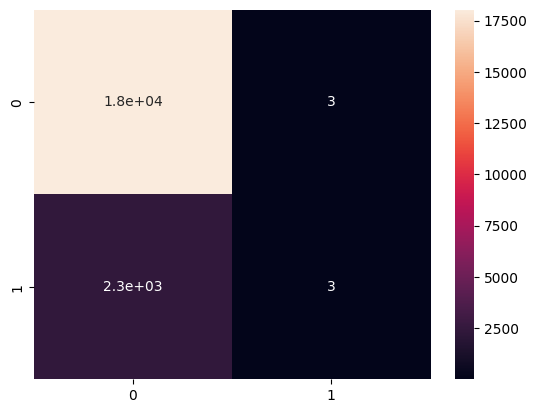

In [43]:
c_matrix = confusion_matrix(y_test, clasificacion)
print(c_matrix)

sns.heatmap(c_matrix, annot=True)

- ### Curva precisión/recall

In [44]:
""" 
Cómo varía la precisión y sensibilidad respecto a diferentes umbrales de probabilidad
"""

# Primero creamos una tabla para ver como varía la precisión y recall en función del valor umbral

prec, rec, thresholds = precision_recall_curve(y_test, predicciones) # necesitamos la probabilidad de la clase 1
pd.DataFrame({"prec":prec[:-1], "rec":rec[:-1], "threshold":thresholds})[80:100]

,prec,rec,threshold
80,0.115468,0.999147,0.017140
81,0.115474,0.999147,0.017163
82,0.115479,0.999147,0.017196
83,0.115485,0.999147,0.017233
84,0.115491,0.999147,0.017304
85,0.115496,0.999147,0.017363
86,0.115502,0.999147,0.017374
87,0.115508,0.999147,0.017384
88,0.115514,0.999147,0.017401
89,0.115470,0.998721,0.017405


Text(0.5, 1.0, 'PR Curve')

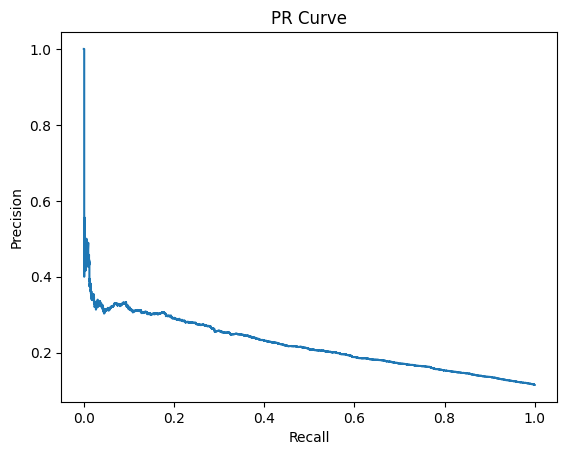

In [45]:
plt.plot(rec, prec)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("PR Curve")

- ### Curva ROC

In [46]:

""" 
- tpr (True Positive Rate / Sensibilidad / Recall): Porcentaje de casos positivos (1) reales que el modelo logra detectar
- fpr (False Positive Rate / 1 - Especificidad): Porcentaje de casos negativos (0) reales que el modelo clasifica erróneamente como positivos.
- threshold: El umbral de probabilidad utilizado para obtener esa combinación específica de tpr y fpr.

"""

fpr, tpr, threshold = roc_curve(y_test, predicciones)
pd.DataFrame({"tpr":tpr, "fpr":fpr, "threshold":threshold})

,tpr,fpr,threshold
0,0.000000,0.000000,inf
1,0.000426,0.000000,0.617048
2,0.000853,0.000000,0.551655
3,0.000853,0.000166,0.503786
4,0.001279,0.000166,0.501509
...,...,...,...
3971,0.999147,0.998447,0.014545
3972,0.999574,0.998447,0.014508
3973,0.999574,0.999834,0.011684
3974,1.000000,0.999834,0.011481


Text(0.5, 1.0, 'Curva ROC')

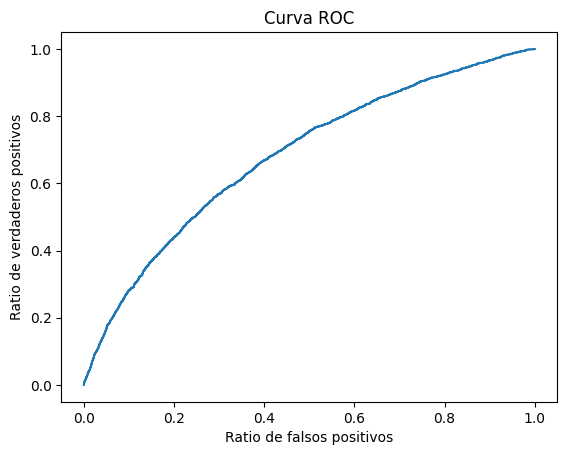

In [47]:
plt.plot(fpr, tpr)

plt.xlabel("Ratio de falsos positivos")
plt.ylabel("Ratio de verdaderos positivos")
plt.title("Curva ROC")